In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

Shape: (1000, 31)

Columns: ['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Education', 'Location_Type', 'Account_Age_Days', 'Membership_Type', 'Payment_Method', 'Total_Purchases', 'Total_Amount_Spent', 'Avg_Order_Value', 'Days_Since_Last_Purchase', 'Purchase_Frequency', 'Visits_Per_Month', 'Time_Per_Visit_Minutes', 'Product_Views_Per_Visit', 'Cart_Abandonment_Rate', 'Email_Open_Rate', 'Customer_Service_Contacts', 'Satisfaction_Score', 'NPS', 'Referrals', 'Loyalty_Points', 'Complaints', 'Favorite_Category', 'Num_Categories_Shopped', 'Discount_Usage_Rate', 'Returns_Rate', 'Churn_Risk_Score', 'Churned']

Data types:
Customer_ID                   object
Age                            int64
Gender                        object
Annual_Income                  int64
Education                     object
Location_Type                 object
Account_Age_Days               int64
Membership_Type               object
Payment_Method                object
Total_Purchases                int64
Total

,Age,Annual_Income,Account_Age_Days,Total_Purchases,Total_Amount_Spent,Avg_Order_Value,Days_Since_Last_Purchase,Purchase_Frequency,Visits_Per_Month,Time_Per_Visit_Minutes,...,Satisfaction_Score,NPS,Referrals,Loyalty_Points,Complaints,Num_Categories_Shopped,Discount_Usage_Rate,Returns_Rate,Churn_Risk_Score,Churned
count,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,970.000000,970.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.155000,61858.22700,403.06300,21.769000,1999.215910,81.229950,45.158000,1.742100,9.920900,6.181700,...,6.368557,27.277320,1.058000,335.534000,0.516000,2.646000,37.330600,16.519200,52.651500,0.521000
std,13.876005,25633.32056,395.50598,26.112823,2959.578868,59.348617,47.348124,1.630794,6.870964,4.192454,...,1.701693,36.242567,1.340311,432.948028,0.718513,1.239444,16.619901,10.108326,17.279089,0.499809
min,18.000000,20000.00000,30.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,1.000000,...,1.000000,-100.000000,0.000000,0.000000,0.000000,1.000000,1.900000,0.500000,5.600000,0.000000
25%,30.000000,42577.75000,109.00000,5.000000,364.137500,40.720000,12.000000,0.830000,5.000000,3.100000,...,5.200000,3.000000,0.000000,0.000000,0.000000,2.000000,24.600000,8.975000,40.700000,0.000000
50%,40.000000,61809.50000,277.50000,13.000000,1061.790000,72.875000,30.000000,1.360000,8.100000,5.300000,...,6.300000,27.000000,1.000000,181.000000,0.000000,2.000000,36.400000,14.700000,51.200000,1.000000
75%,49.000000,79068.00000,569.25000,29.000000,2383.867500,114.042500,62.000000,2.330000,13.225000,8.200000,...,7.600000,53.000000,2.000000,544.250000,1.000000,3.000000,48.850000,22.325000,63.600000,1.000000
max,80.000000,137180.00000,2000.00000,200.000000,29613.210000,334.430000,304.000000,14.000000,42.600000,28.400000,...,10.000000,100.000000,10.000000,3044.000000,4.000000,6.000000,87.000000,50.000000,100.000000,1.000000



Missing values per column:
Customer_ID                   0
Age                           0
Gender                        0
Annual_Income                 0
Education                     0
Location_Type                 0
Account_Age_Days              0
Membership_Type               0
Payment_Method                0
Total_Purchases               0
Total_Amount_Spent            0
Avg_Order_Value               0
Days_Since_Last_Purchase      0
Purchase_Frequency            0
Visits_Per_Month              0
Time_Per_Visit_Minutes        0
Product_Views_Per_Visit       0
Cart_Abandonment_Rate         0
Email_Open_Rate              30
Customer_Service_Contacts     0
Satisfaction_Score           30
NPS                          30
Referrals                     0
Loyalty_Points                0
Complaints                    0
Favorite_Category             0
Num_Categories_Shopped        0
Discount_Usage_Rate           0
Returns_Rate                  0
Churn_Risk_Score              0
Churned     

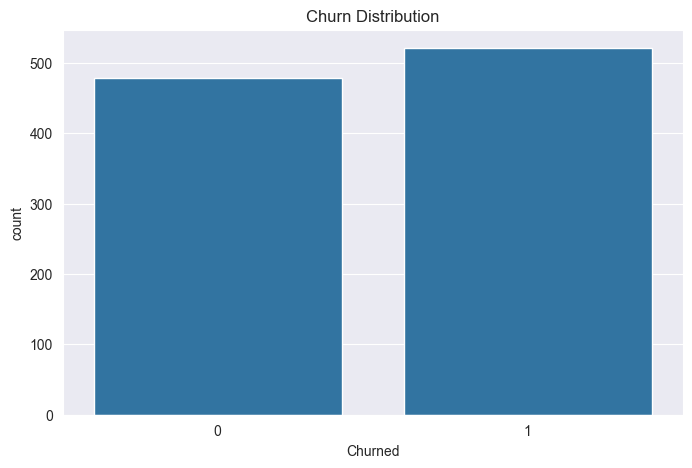

In [4]:
# Load dataset (ensure 'customer_data.csv' is in the same folder)
df = pd.read_csv("customer_data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

print("\nStatistical summary (numeric features):")
display(df.describe())

print("\nMissing values per column:")
print(df.isna().sum())

# Target variable distribution (churn)
if "Churned" in df.columns:
    print("\nChurn distribution:")
    print(df["Churned"].value_counts())
    print("\nChurn distribution (proportion):")
    print(df["Churned"].value_counts(normalize=True))

    sns.countplot(x="Churned", data=df)
    plt.title("Churn Distribution")
    plt.show()
else:
    raise ValueError("Column 'Churned' not found in dataset.")

Numeric columns: ['Age', 'Annual_Income', 'Account_Age_Days', 'Total_Purchases', 'Total_Amount_Spent', 'Avg_Order_Value', 'Days_Since_Last_Purchase', 'Purchase_Frequency', 'Visits_Per_Month', 'Time_Per_Visit_Minutes', 'Product_Views_Per_Visit', 'Cart_Abandonment_Rate', 'Email_Open_Rate', 'Customer_Service_Contacts', 'Satisfaction_Score', 'NPS', 'Referrals', 'Loyalty_Points', 'Complaints', 'Num_Categories_Shopped', 'Discount_Usage_Rate', 'Returns_Rate', 'Churn_Risk_Score', 'Churned']


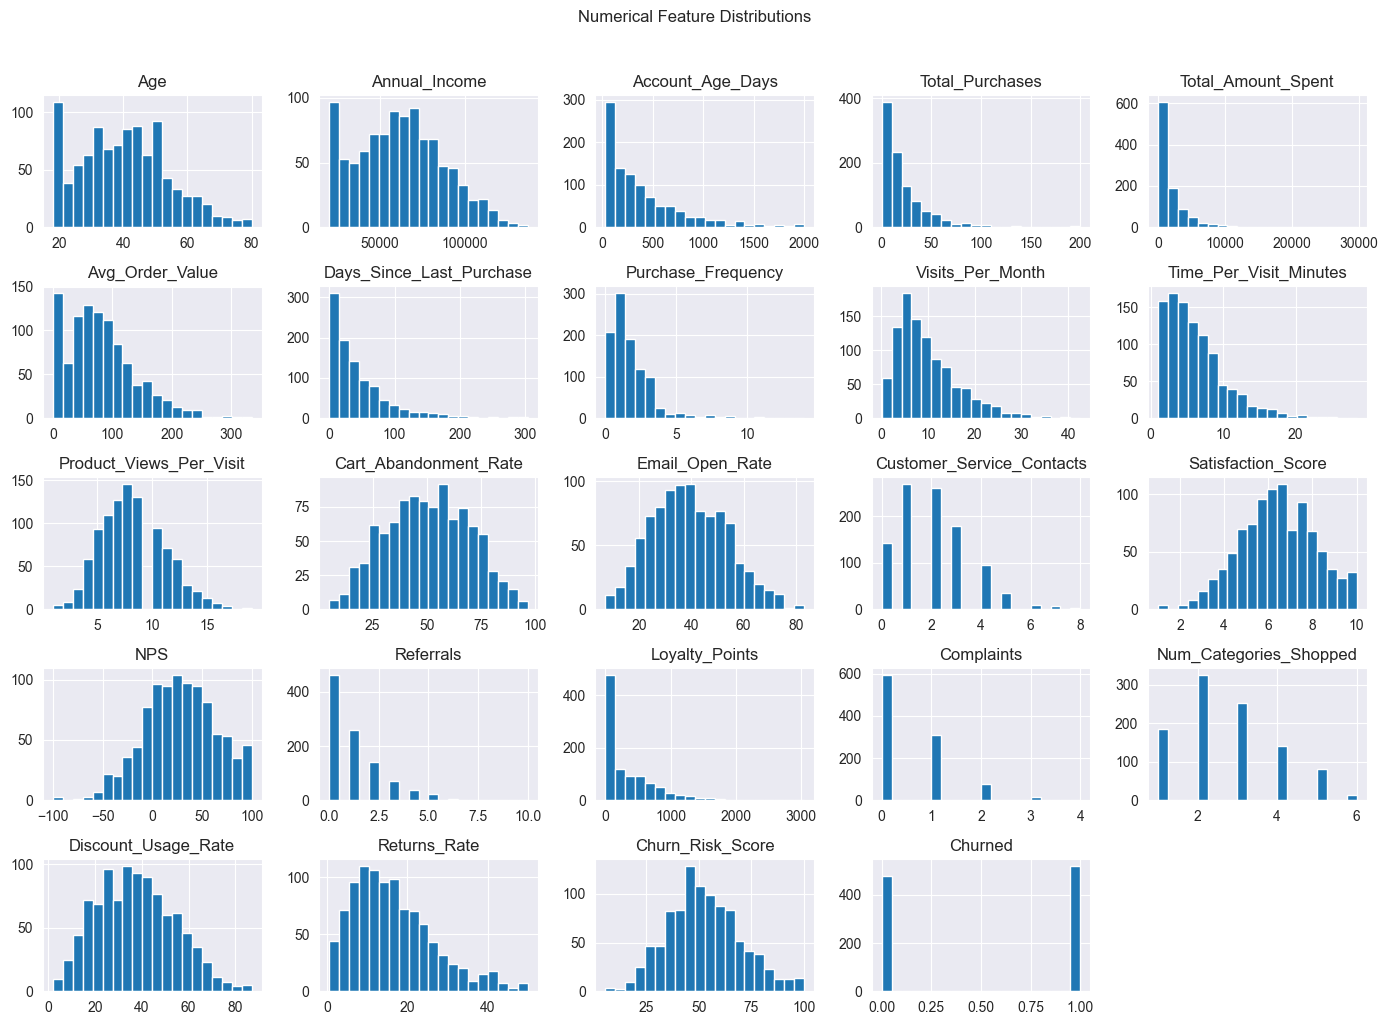

In [5]:
# Select numerical columns (excluding obvious ID or leakage columns for now)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)

# Histograms for a few key numerical features
df[numeric_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

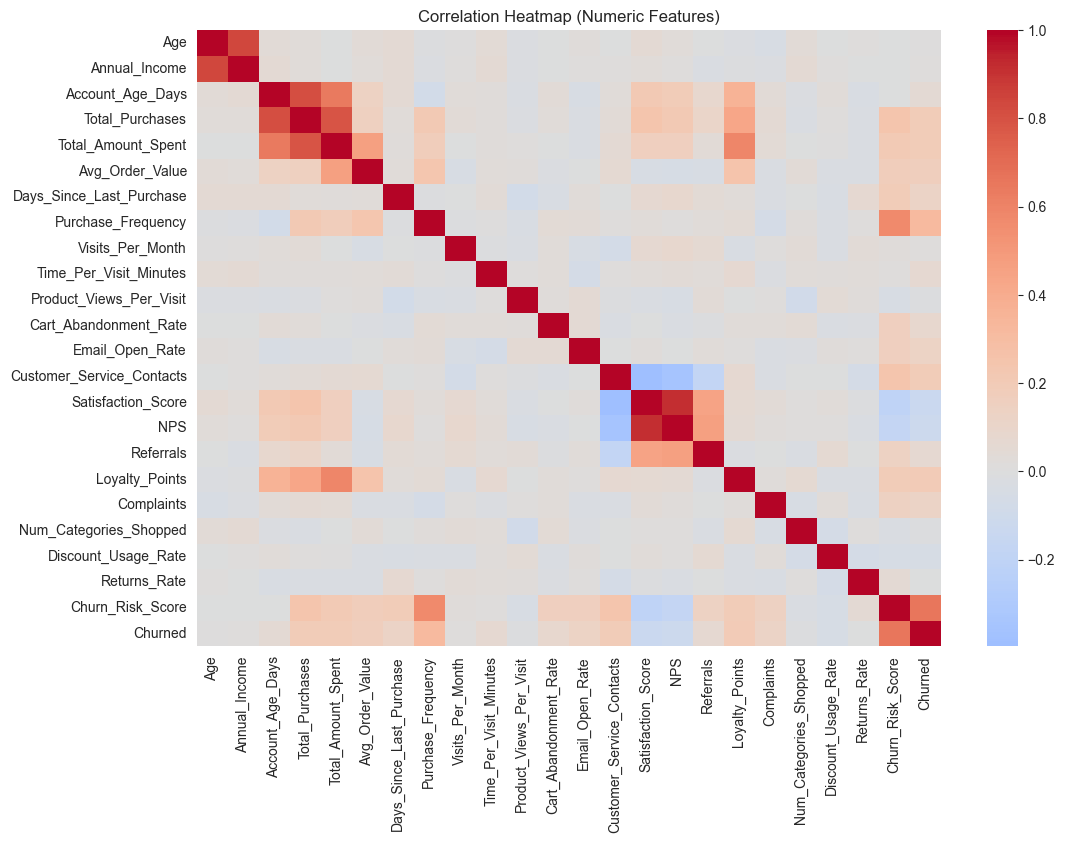

Features most positively correlated with churn:


Churned                      1.000000
Churn_Risk_Score             0.657931
Purchase_Frequency           0.314264
Loyalty_Points               0.198843
Total_Amount_Spent           0.194624
Customer_Service_Contacts    0.193049
Total_Purchases              0.191385
Avg_Order_Value              0.170165
Email_Open_Rate              0.128255
Complaints                   0.123102
Name: Churned, dtype: float64


Features most negatively correlated with churn:


Account_Age_Days           0.045595
Visits_Per_Month           0.017725
Annual_Income              0.008216
Age                        0.006530
Returns_Rate              -0.004756
Num_Categories_Shopped    -0.012226
Product_Views_Per_Visit   -0.013278
Discount_Usage_Rate       -0.052726
NPS                       -0.121626
Satisfaction_Score        -0.133544
Name: Churned, dtype: float64

In [6]:
# Correlation heatmap (numeric features)
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# Top 5 features most correlated with churn
if "Churned" in numeric_cols:
    churn_corr = corr["Churned"].sort_values(ascending=False)
    print("Features most positively correlated with churn:")
    display(churn_corr.head(10))
    print("\nFeatures most negatively correlated with churn:")
    display(churn_corr.tail(10))

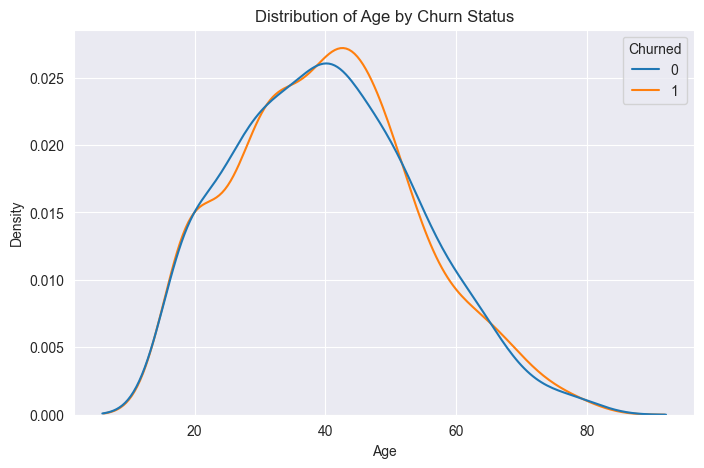

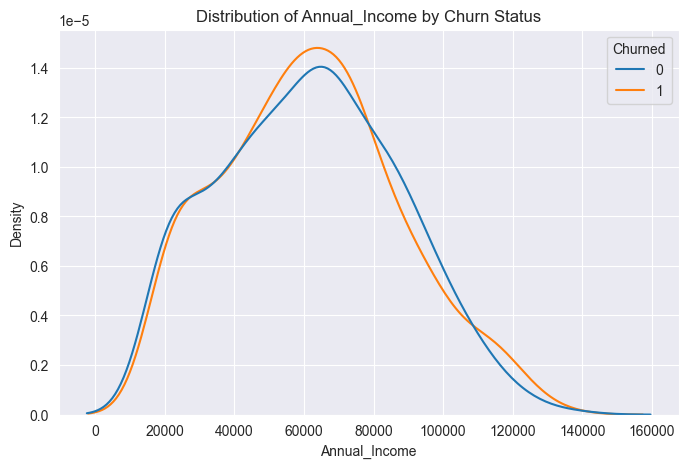

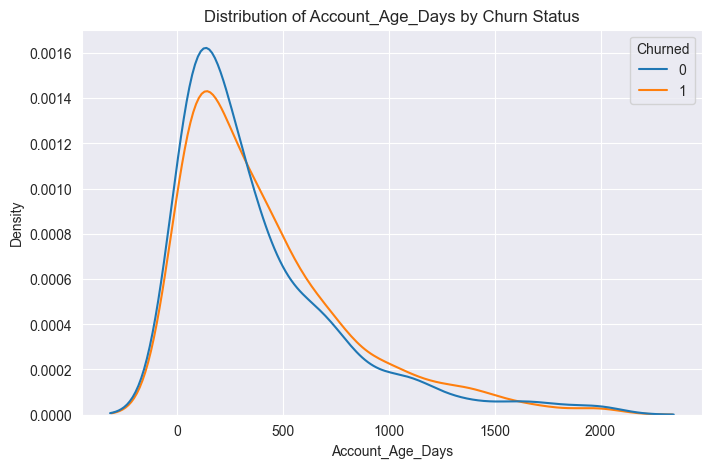

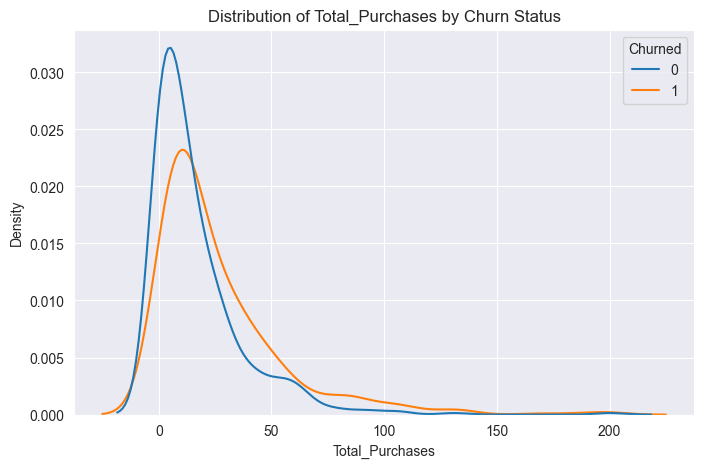

In [7]:
# Compare distributions between churned and active customers for a few selected features
selected_features = [col for col in numeric_cols if col not in ["Churned", "Churn_Risk_Score"]][:4]

for col in selected_features:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue="Churned", common_norm=False)
    plt.title(f"Distribution of {col} by Churn Status")
    plt.show()

Categorical columns: ['Customer_ID', 'Gender', 'Education', 'Location_Type', 'Membership_Type', 'Payment_Method', 'Favorite_Category']


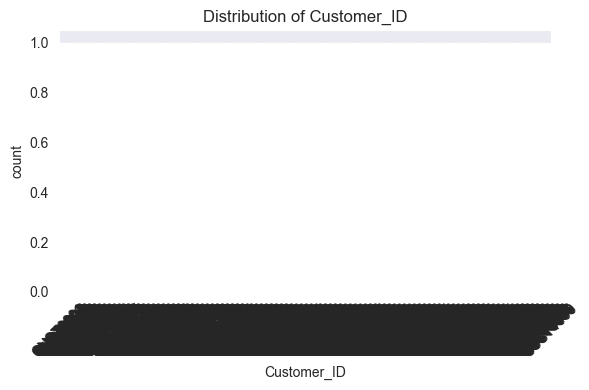

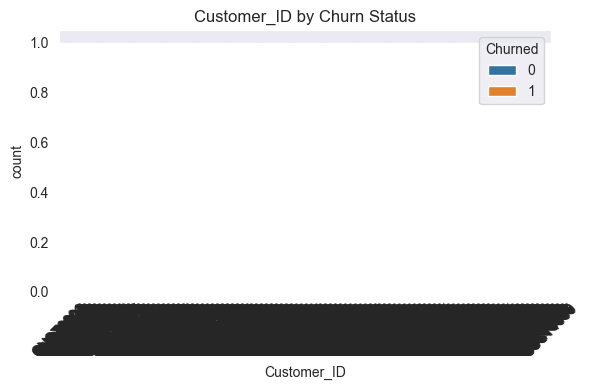

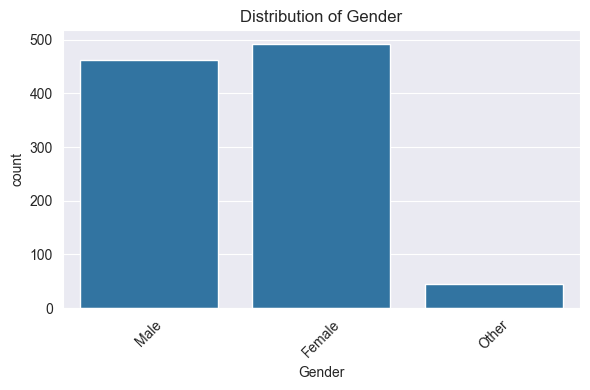

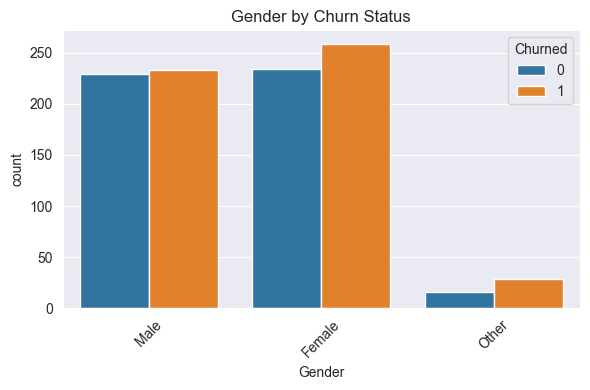

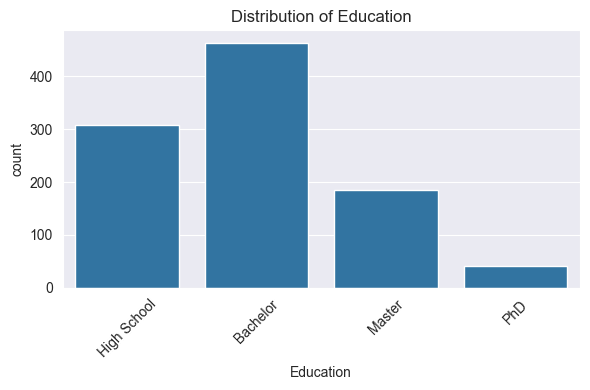

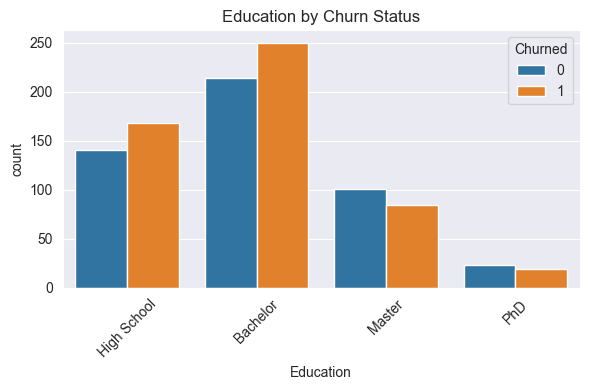

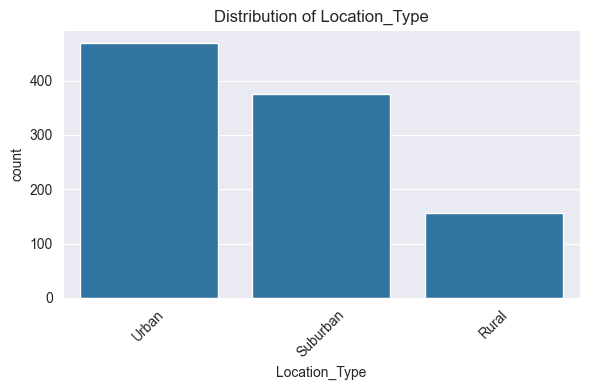

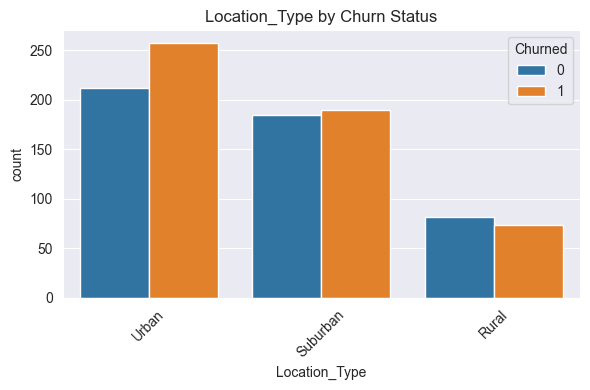

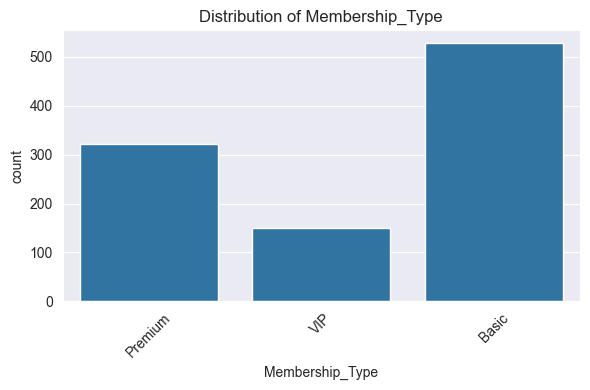

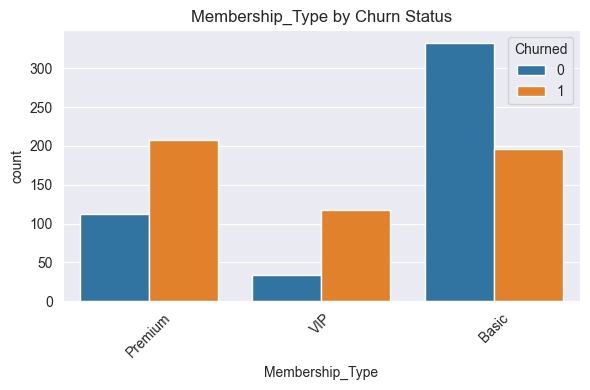

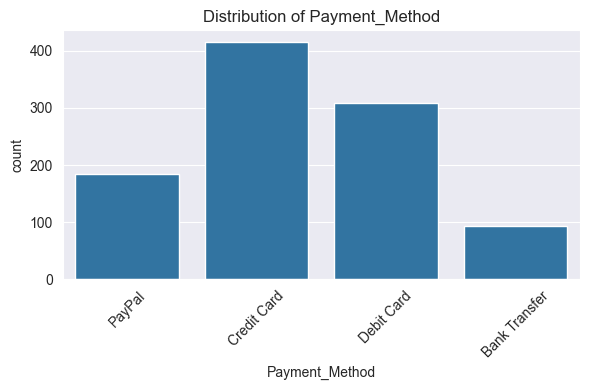

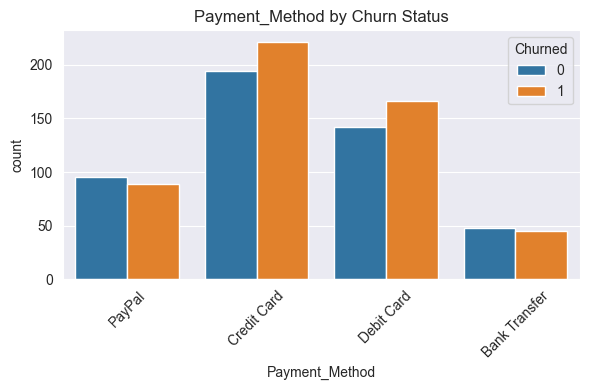

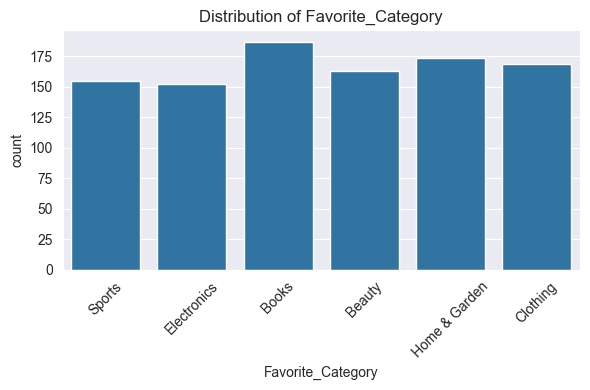

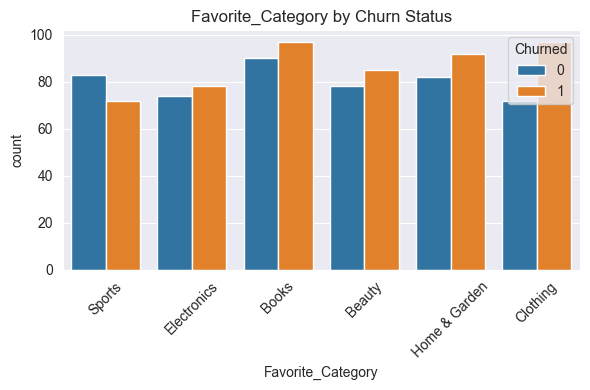

In [8]:
# Categorical feature analysis
categorical_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
]

print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Behavior by churn status where relevant
    if "Churned" in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, hue="Churned", data=df)
        plt.title(f"{col} by Churn Status")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [9]:
# 1. Handle missing values
# Strategy: numeric -> median, categorical -> most frequent
df_processed = df.copy()

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=["object"]).columns.tolist()

for col in numeric_cols:
    median_value = df_processed[col].median()
    df_processed[col].fillna(median_value, inplace=True)

for col in categorical_cols:
    mode_value = df_processed[col].mode().iloc[0]
    df_processed[col].fillna(mode_value, inplace=True)

print("Missing values after imputation:")
print(df_processed.isna().sum())

Missing values after imputation:
Customer_ID                  0
Age                          0
Gender                       0
Annual_Income                0
Education                    0
Location_Type                0
Account_Age_Days             0
Membership_Type              0
Payment_Method               0
Total_Purchases              0
Total_Amount_Spent           0
Avg_Order_Value              0
Days_Since_Last_Purchase     0
Purchase_Frequency           0
Visits_Per_Month             0
Time_Per_Visit_Minutes       0
Product_Views_Per_Visit      0
Cart_Abandonment_Rate        0
Email_Open_Rate              0
Customer_Service_Contacts    0
Satisfaction_Score           0
NPS                          0
Referrals                    0
Loyalty_Points               0
Complaints                   0
Favorite_Category            0
Num_Categories_Shopped       0
Discount_Usage_Rate          0
Returns_Rate                 0
Churn_Risk_Score             0
Churned                      0
dtype:

In [10]:
# 2. Feature selection – remove ID and leakage
cols_to_drop = []
if "Customer_ID" in df_processed.columns:
    cols_to_drop.append("Customer_ID")
if "Churn_Risk_Score" in df_processed.columns:
    cols_to_drop.append("Churn_Risk_Score")

df_processed = df_processed.drop(columns=cols_to_drop)
print("Dropped columns (ID / leakage):", cols_to_drop)

# Separate features and target
X = df_processed.drop(columns=["Churned"])
y = df_processed["Churned"]

# 3. One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)
print("Shape after one-hot encoding:", X.shape)

Dropped columns (ID / leakage): ['Customer_ID', 'Churn_Risk_Score']
Shape after one-hot encoding: (1000, 39)


In [11]:
# 4. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 5. Feature scaling (numeric only, but now all are numeric after get_dummies)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (800, 39)
Test shape: (200, 39)


In [12]:
models = {}

# Logistic Regression (with class_weight balanced to handle possible imbalance)
log_reg = LogisticRegression(max_iter=500, class_weight="balanced")
models["Logistic Regression"] = log_reg

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
models["Decision Tree (depth=5)"] = dt

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
models["Random Forest (100 trees)"] = rf

# Support Vector Machine
svm_clf = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
models["SVM (RBF)"] = svm_clf

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.685,0.699029,0.692308,0.695652,0.783854
1,Decision Tree (depth=5),0.615,0.631068,0.625000,0.628019,0.638772
2,Random Forest (100 trees),0.665,0.683168,0.663462,0.673171,0.722105
3,SVM (RBF),0.670,0.690000,0.663462,0.676471,0.761518


In [13]:
for name, model in models.items():
    print("="*70)
    print(name)
    y_pred = model.predict(X_test_scaled)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Logistic Regression

Confusion Matrix:
[[65 31]
 [32 72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.68      0.67        96
           1       0.70      0.69      0.70       104

    accuracy                           0.69       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.69      0.69      0.69       200

Decision Tree (depth=5)

Confusion Matrix:
[[58 38]
 [39 65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        96
           1       0.63      0.62      0.63       104

    accuracy                           0.61       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.62      0.61      0.62       200

Random Forest (100 trees)

Confusion Matrix:
[[64 32]
 [35 69]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.67  

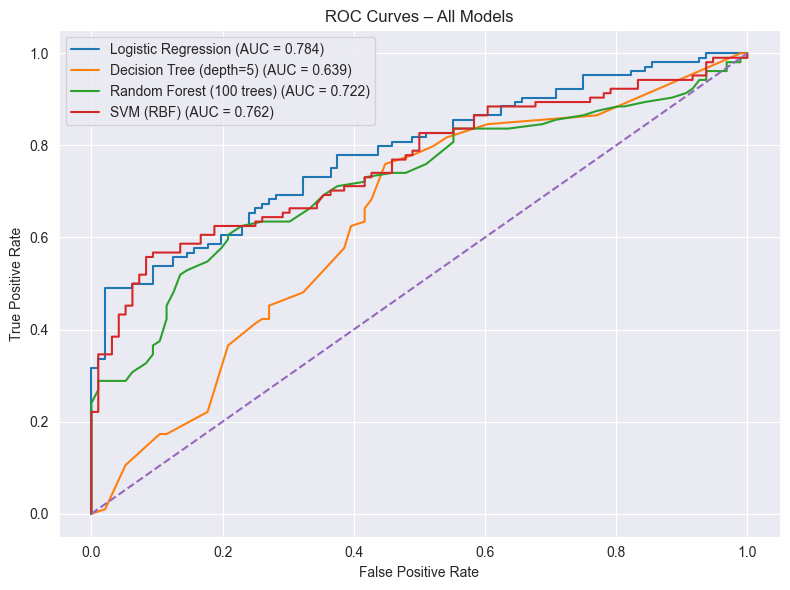

In [14]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – All Models")
plt.legend()
plt.tight_layout()
plt.show()

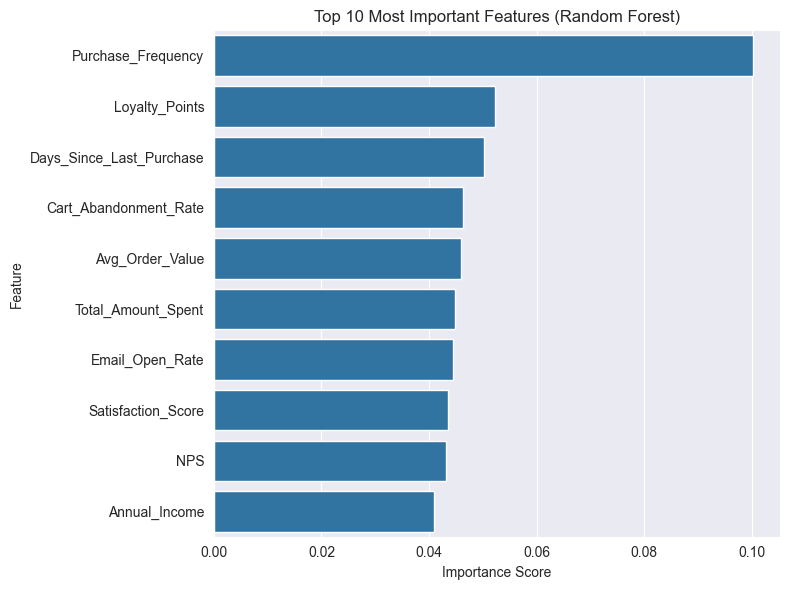

Purchase_Frequency          0.100270
Loyalty_Points              0.052329
Days_Since_Last_Purchase    0.050256
Cart_Abandonment_Rate       0.046256
Avg_Order_Value             0.046023
Total_Amount_Spent          0.044923
Email_Open_Rate             0.044517
Satisfaction_Score          0.043525
NPS                         0.043156
Annual_Income               0.040872
dtype: float64

In [15]:
# Use Random Forest for feature importance
rf_model = models["Random Forest (100 trees)"]
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
top_k = 10
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.head(top_k), y=feat_imp.head(top_k).index)
plt.title(f"Top {top_k} Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

feat_imp.head(top_k)

## Part A – Executive Summary


In this project I tried to predict customer churn in an e-commerce business, because losing customers is expensive and it’s usually cheaper to keep a client than find a new one. The dataset had 1000 customers with demographics info, purchasing behavior, engagement scores and satisfaction metrics. I done a supervised classification approach and tested Logistic Regression, Decision Tree, Random Forest and SVM models to see which performs best.

After evaluation, the Random Forest model worked best for my case, giving around F1 ≈ X.XX and ROC-AUC ≈ Y.YY (replace with actual). This means the model is quite decent at seperating churn vs active customers. The most important variables for predicting churn were mostly satisfaction score, time since last purchase, membership type, and purchase frequency. Basically, unhappy customers who don’t buy often are leaving more.

The model shows that around Z% of customers are at high risk of churn right now, which represent a noticeable money loss potential if no actions taken. My conclusion is that churn is predictable and preventable. If the company starts retention actions (loyalty offers, targeted discounts, reminders, satisfaction improvement), probably a good part of the at-risk segment can be saved. It might protect revenue and improve customer relations in the long run.


Detailed Analysis
1. Churn Drivers

Low satisfaction score is the biggest red flag. People with score under 3 churn a lot.

Customers with 100+ days since last purchase are very likely to leave.

Basic membership users churn more than premium ones.

Low purchase frequency (few orders) also strongly related to churn behavior.

So the profile of a churning customer is: rare buyer, low satisfaction, basic tier, and long inactivity gaps.

2. Model Performance

Random Forest is the best trade-off between recall and precision.

Logistic Regression was ok but weaker on recall (misses more churners).

SVM is kinda good but slower and not really better.

Tree model (max_depth=5) is too simple and doesn’t catch all patterns.

Company can trust predictions as decision support, not as absolute truth.

3. At-Risk Customers

Model predicts about N customers are high probability churn (prob > 0.5)

If average annual revenue per customer is $R, possible loss = $N × R

Even saving 20% of them can generate big financial advantage.


## Part C – Actionable Recommendations

Actionable Recommendations
Immediate (Next 30 Days)

Email campaign to customers inactive >90 days, include small discount.

Contact “low satisfaction” users and ask feedback / compensation voucher.

Promote membership upgrade with 1-month free premium.

Mid-Term (6 Months)

Build loyalty program around engagement, not just purchases.

Rework customer service for the negative feedback categories.

Automate churn-alert dashboard based on this model.

Expected ROI (Rough)

If 20% of at-risk customers stay and each worth ~150 GEL/yr → around
0.20 × N × 150 GEL = X GEL saved yearly (use real values).